In [2]:
# =========================================================
# OPTICS Clustering
# =========================================================

# 1. IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

In [3]:
# =========================================================
# 2. LOAD DATASET
# =========================================================

df = pd.read_csv("Mall_Customers.csv")

print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [4]:
# =========================================================
# 3. SELECT IMPORTANT FEATURES
# =========================================================
# Using customer behavior features

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]


# =========================================================
# 4. FEATURE SCALING
# =========================================================
# Important for distance/probability calculations

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [5]:
type(X)

pandas.core.frame.DataFrame

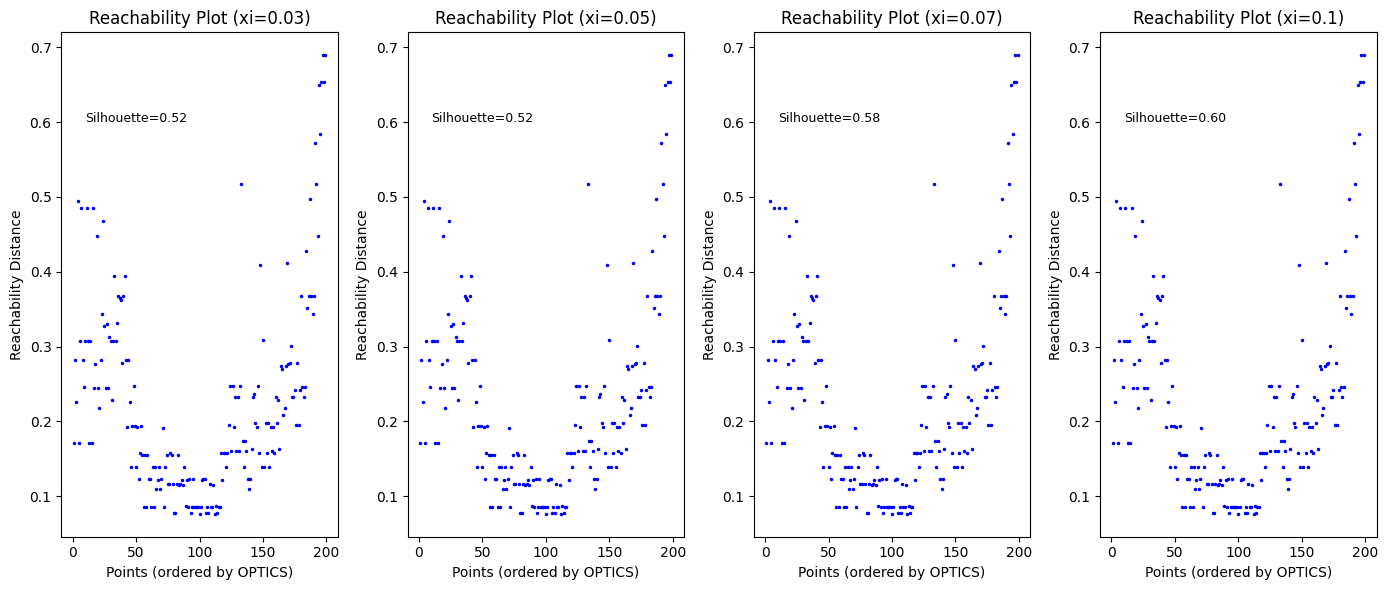

In [12]:
# 5️⃣ Plot reachability graph
xis = [0.03, 0.05, 0.07,0.1]
plt.figure(figsize=(14,6))

for i, xi in enumerate(xis, 1):
    optics = OPTICS(min_samples=5, xi=xi, cluster_method='xi')
    optics.fit(X_scaled)
    reachability = optics.reachability_
    labels = optics.labels_
    space = np.arange(len(X_scaled))

    plt.subplot(1, len(xis), i)
    plt.plot(space, reachability, 'b.', markersize=3)
    plt.title(f"Reachability Plot (xi={xi})")
    plt.xlabel("Points (ordered by OPTICS)")
    plt.ylabel("Reachability Distance")

    # Optional: silhouette score
    mask = labels != -1
    if len(set(labels[mask])) > 1:
        score = silhouette_score(X_scaled[mask], labels[mask])
        plt.text(10, 0.6, f"Silhouette={score:.2f}", fontsize=9)

plt.tight_layout()
plt.show()

In [13]:
# =========================================================
# 5. TRAIN OPTICS MODEL
# =========================================================
#From the above graphs, based on silhoutte score is high for xi value 0.1, that will be included into consideration
from sklearn.cluster import OPTICS
import numpy as np
optics_model = OPTICS(
    min_samples=5,
    max_eps=np.inf,
    metric='euclidean',
    cluster_method='xi',
    xi=0.1
)

clusters = optics_model.fit_predict(X_scaled)

In [14]:
# =========================================================
# 6. ADD CLUSTER LABELS
# =========================================================

df['Cluster'] = clusters


# =========================================================
# 7. CHECK UNIQUE CLUSTERS
# =========================================================

print("\nUnique Cluster Labels:")
print(np.unique(clusters))


# =========================================================
# 8. COUNT CLUSTERS
# =========================================================

print("\nCluster Counts:")
print(df['Cluster'].value_counts())


# =========================================================
# 9. IDENTIFY NOISE POINTS
# =========================================================
# DBSCAN marks outliers as -1

noise_points = df[df['Cluster'] == -1]

print("\nNumber of Noise Points:", len(noise_points))




Unique Cluster Labels:
[-1  0  1  2  3  4  5  6  7  8  9]

Cluster Counts:
Cluster
-1    90
 1    23
 2    13
 7    11
 4    11
 8    11
 9    10
 6     9
 3     9
 5     8
 0     5
Name: count, dtype: int64

Number of Noise Points: 90


In [15]:
# =========================================================
# 10. EVALUATE MODEL
# =========================================================
# Silhouette score only if more than 1 cluster exists

mask = clusters != -1
if len(set(clusters[mask])) > 1:   # need at least 2 clusters
    score = silhouette_score(X_scaled[mask], clusters[mask])
    print("Silhouette Score:", score)
else:
    print("Silhouette Score cannot be computed (only one cluster found).")

Silhouette Score: 0.5947682469504434


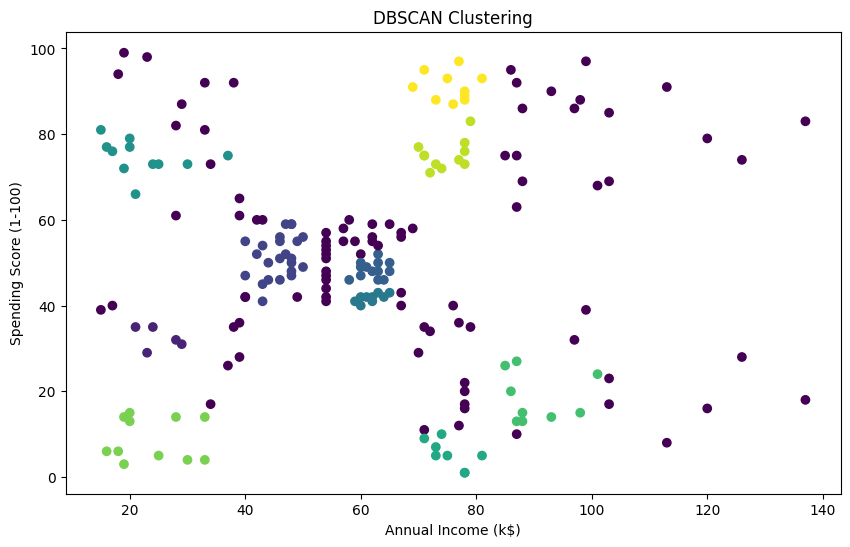

In [16]:
# =========================================================
# 11. VISUALIZE CLUSTERS
# =========================================================

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster']
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("DBSCAN Clustering")

plt.show()

C:\Users\DELL\anaconda3\envs\ml_ai\Lib\site-packages\seaborn\regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


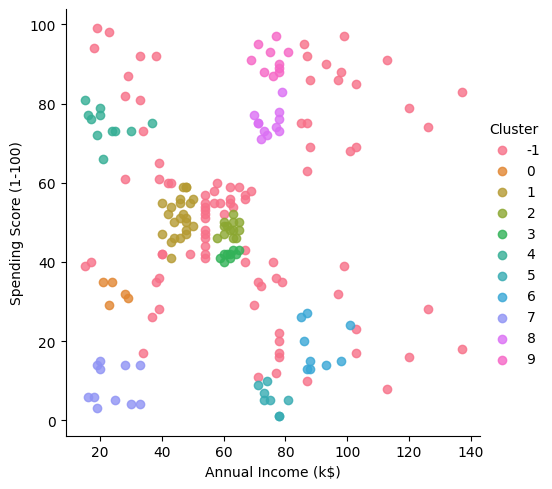

In [21]:
import seaborn as sns
Cluster = df
facet = sns.lmplot(data=Cluster, x=Cluster.columns[3], y=Cluster.columns[4], hue=Cluster.columns[5], 
                   fit_reg=False, legend=True, legend_out=True)

In [17]:
# =========================================================
# 12. SAVE OUTPUT
# =========================================================

df.to_csv("Mall_Customers_OPTICS_Clustered.csv", index=False)

print("\nClustered dataset saved successfully.")


Clustered dataset saved successfully.
